In [1]:
%matplotlib inline

import sys
import yaml
import copy

import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.yolov11_pose.data.dataset import YOLODataset
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.misc import alpha_bending, instance2mask

In [2]:
from matplotlib import patches
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

In [3]:
args=parser.parse_args('--deterministic'.split())

task='detect'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco8-pose'
    data_config='../../coco8-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco8'
    data_config='../../coco8.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg'
    data_config='../../coco8-seg.yaml'
    
dataset=YOLODataset(args=args, data=data_config, task=task, img_path=data_dirpath, imgsz=640, cache=False,augment=True, 
                    hyp=DEFAULT_CFG_DICT, prefix='',rect=False,batch_size=16,stride=32,pad=0.5, single_cls=False,classes=None,
                fraction=1.,channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)

Scanning D:\data\ultralytics\coco8\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
(8, 1)
(2, 1)
(2, 1)
(1, 1)


In [4]:
from __future__ import annotations

import math
import random
from copy import deepcopy
from typing import Any

import cv2
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F

from computer_vision.yolov11_pose.data.augment import BaseMixTransform, Mosaic, MixUp, LetterBox

In [5]:
indx=0
labels=dataset.get_image_and_label(indx) # main label
pre_transform=LetterBox(new_shape=(640,640), auto=False, center=True)
labels=pre_transform(labels)
orig_labels=copy.deepcopy(labels)

aug_op=MixUp(dataset=dataset, pre_transform=pre_transform, p=1.)

# --- This is part of __call__ in Base class
indexes=aug_op.get_indexes()
if isinstance(indexes, int): indexes=[indexes]
print('indexes ', indexes)

# Get images information will be used for Mosaic, CutMix or Mixup
mix_labels=[aug_op.dataset.get_image_and_label(i) for i in indexes] 
if aug_op.pre_transform is not None:
    for i, data in enumerate(mix_labels): mix_labels[i]=aug_op.pre_transform(data)
labels['mix_labels']=mix_labels
final_labels=aug_op._mix_transform(labels)

Before auto dw 0, dh 160 current shape (480, 640)
indexes  [5]
Before auto dw 0, dh 162 current shape (478, 640)


0 --------------------------------------------------
img  (640, 640, 3) height 640, width 640
1 --------------------------------------------------
img  (640, 640, 3) height 640, width 640


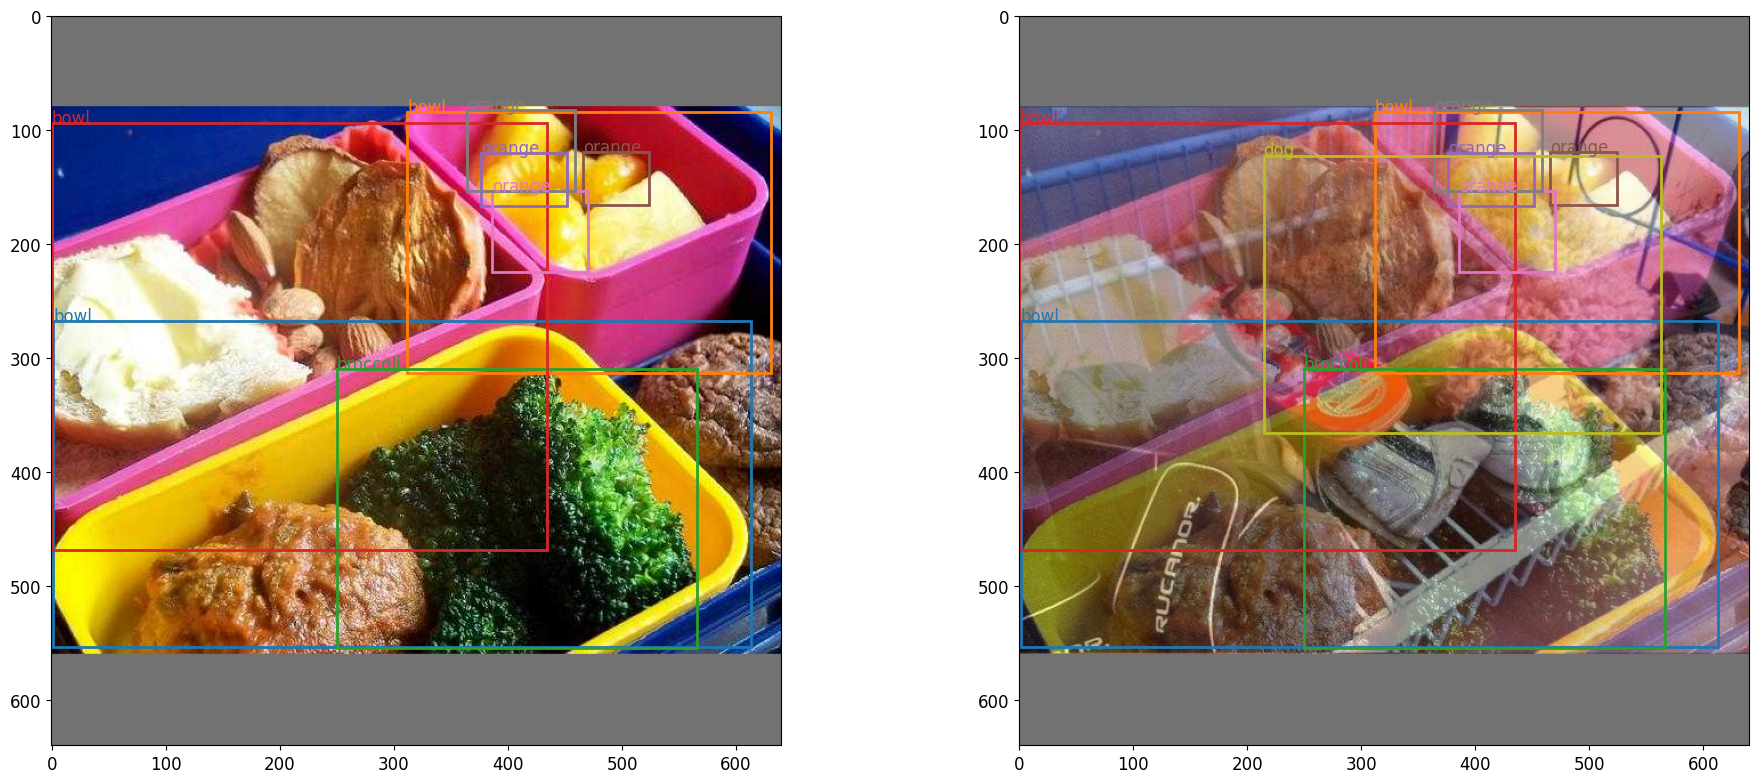

In [6]:
_, ax=plt.subplots(1,2,figsize=(20,8))
for i, labels in enumerate([orig_labels, final_labels]):
    print(i,'-'*50)
    classes=[dataset.data['names'][int(c)] for c in labels['cls'].flatten()]
    img=labels['img']
    height, width=img.shape[:2]
    print('img ', img.shape, f'height {height}, width {width}')
    instances=copy.deepcopy(labels['instances'])
    if instances._bboxes.format=='xywh': instances.convert_bbox('xyxy')
    if instances.normalized: instances.denormalize()
    boxes=instances.bboxes
    if hasattr(labels['instances'], 'segments') and len(getattr(labels['instances'], 'segments')):
        mask=instance2mask(image=img, instance=labels['instances'])
        ax[i].imshow(alpha_bending(mask, img[...,::-1], 0.4))
    else: ax[i].imshow(img[...,::-1])
    for j, (box,cls) in enumerate(zip(boxes, classes)):
        # Create a Rectangle patch
        rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
        # Add the patch to the Axes
        ax[i].add_patch(rect)
        ax[i].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)
plt.tight_layout()